# 🚢 Titanic Survival Prediction
**Tools:** Python · Pandas · Scikit-Learn · Matplotlib · Seaborn

### What this notebook covers
1. Data loading & first look
2. Missing value analysis & imputation
3. Exploratory Data Analysis (5 visualizations)
4. Feature engineering
5. Random Forest classifier
6. Submission file generation

> **Competition:** [Titanic – Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)

In [2]:
import os
# Check what's available
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✅')

Libraries loaded ✅


In [4]:
# Load datasets (Kaggle provides train.csv and test.csv)
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(f'Train shape: {train.shape}   |   Test shape: {test.shape}')
train.head()

Train shape: (891, 12)   |   Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Missing Values Analysis

In [5]:
def missing_summary(df, name='Dataset'):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing': miss, 'Pct (%)': pct})
    summary = summary[summary['Missing'] > 0].sort_values('Pct (%)', ascending=False)
    print(f'\n── {name} ──')
    print(summary.to_string())
    return summary

missing_summary(train, 'Train')
missing_summary(test,  'Test')


── Train ──
          Missing  Pct (%)
Cabin         687    77.10
Age           177    19.87
Embarked        2     0.22

── Test ──
       Missing  Pct (%)
Cabin      327    78.23
Age         86    20.57
Fare         1     0.24


,Missing,Pct (%)
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


In [6]:
# ── Imputation ──────────────────────────────────────────────────────────────
# Age  → median by Pclass + Sex (better than global median)
for df in [train, test]:
    df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

# Embarked → most frequent (2 rows in train)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Fare → median of same Pclass (1 row in test)
test['Fare'].fillna(test.groupby('Pclass')['Fare'].transform('median'), inplace=True)

# Cabin has >75 % missing – drop it
for df in [train, test]:
    df.drop(columns=['Cabin'], inplace=True)

print('Missing values after imputation:')
print(train.isnull().sum()[train.isnull().sum() > 0])
print('\nAll clean ✅' if train.isnull().sum().sum() == 0 else '')

Missing values after imputation:
Series([], dtype: int64)

All clean ✅


## 3. Exploratory Data Analysis (5 Visualizations)

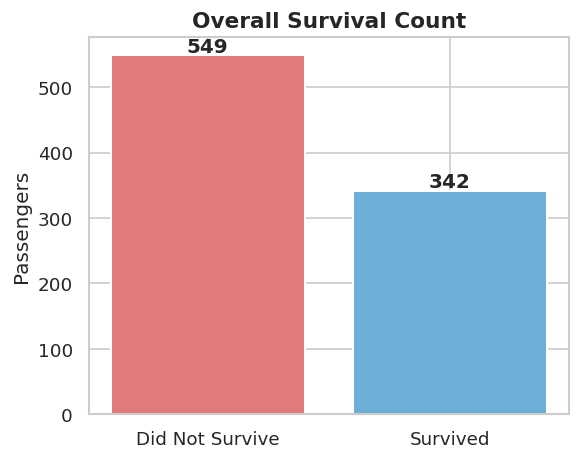

In [7]:
# ── Viz 1: Survival Count ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = train['Survived'].value_counts()
ax.bar(['Did Not Survive', 'Survived'], counts, color=['#e07b7b', '#6baed6'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Overall Survival Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Passengers')
plt.tight_layout()
plt.show()

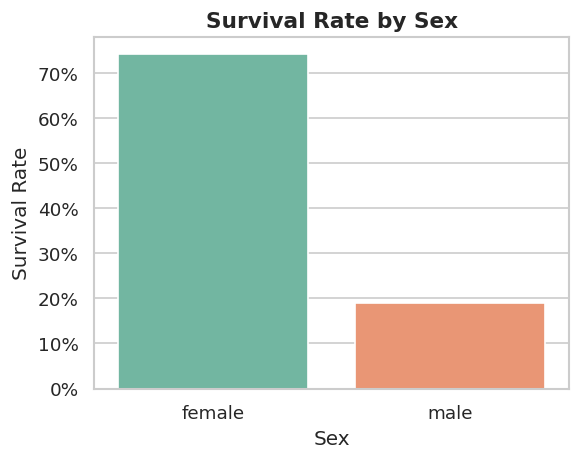

In [8]:
# ── Viz 2: Survival Rate by Sex ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
survival_sex = train.groupby('Sex')['Survived'].mean().reset_index()
sns.barplot(data=survival_sex, x='Sex', y='Survived', palette='Set2', ax=ax)
ax.set_title('Survival Rate by Sex', fontsize=13, fontweight='bold')
ax.set_ylabel('Survival Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

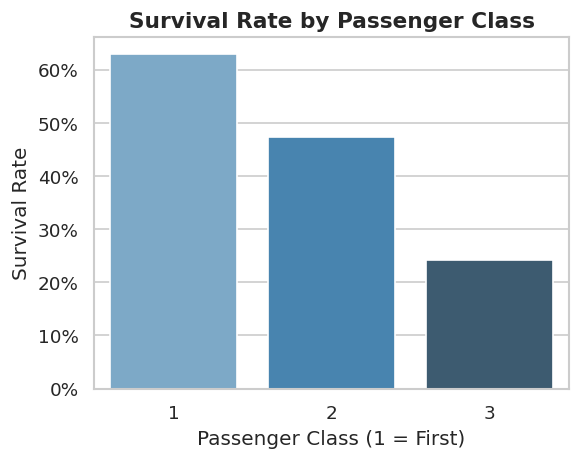

In [9]:
# ── Viz 3: Survival Rate by Passenger Class ──────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
survival_pclass = train.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(data=survival_pclass, x='Pclass', y='Survived', palette='Blues_d', ax=ax)
ax.set_title('Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class (1 = First)')
ax.set_ylabel('Survival Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

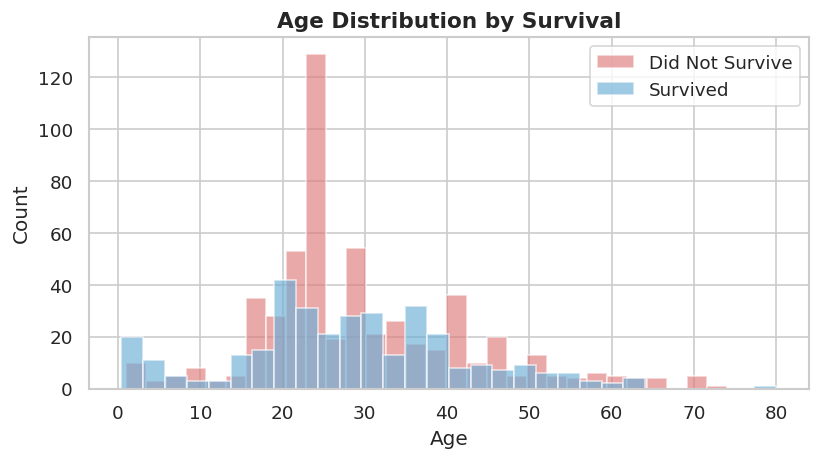

In [10]:
# ── Viz 4: Age Distribution by Survival ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for survived, label, color in zip([0, 1], ['Did Not Survive', 'Survived'], ['#e07b7b', '#6baed6']):
    subset = train[train['Survived'] == survived]['Age']
    ax.hist(subset, bins=30, alpha=0.65, label=label, color=color, edgecolor='white')
ax.set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

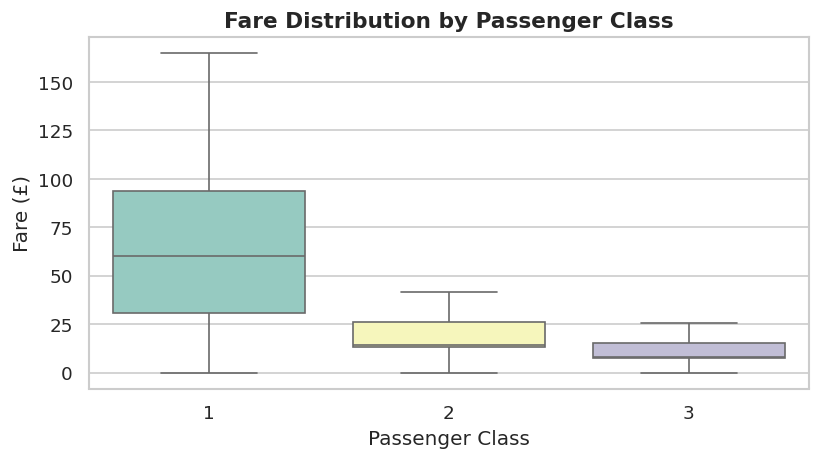

In [11]:
# ── Viz 5: Fare Distribution by Class (Box Plot) ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train, x='Pclass', y='Fare', palette='Set3', ax=ax,
            showfliers=False)   # hide extreme outliers for clarity
ax.set_title('Fare Distribution by Passenger Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare (£)')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [12]:
def engineer_features(df):
    df = df.copy()

    # Title extracted from Name
    df['Title'] = df['Name'].str.extract(r',\s*(\w+)\.', expand=False)
    rare = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # Age bands
    df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 100],
                           labels=[0, 1, 2, 3, 4]).astype(int)

    # Fare bands
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

    # Encode categoricals
    df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df['Title']    = df['Title'].map(
        {'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3, 'Rare': 4}
    ).fillna(4).astype(int)

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'Embarked',
            'FamilySize', 'IsAlone', 'Title']

X_train = train_fe[FEATURES]
y_train = train_fe['Survived']
X_test  = test_fe[FEATURES]

print(f'Feature matrix shape — Train: {X_train.shape} | Test: {X_test.shape}')
X_train.head()
# Extract title from passenger name (Mr, Mrs, Miss, Master)
# Rare titles grouped together to reduce noise

Feature matrix shape — Train: (891, 8) | Test: (418, 8)


,Pclass,Sex,AgeBand,FareBand,Embarked,FamilySize,IsAlone,Title
0,3,0,2,0,0,2,0,0
1,1,1,2,3,1,2,0,1
2,3,1,2,1,0,1,1,2
3,1,1,2,3,0,2,0,1
4,3,0,2,1,0,1,1,0


## 5. Random Forest Classifier

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f'CV Accuracy:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold:     {np.round(cv_scores, 4)}')

# Fit on full training data
rf.fit(X_train, y_train)
train_acc = accuracy_score(y_train, rf.predict(X_train))
print(f'\nTrain Accuracy (full fit): {train_acc:.4f}')

CV Accuracy:  0.8249 ± 0.0133
Per-fold:     [0.8156 0.8258 0.8258 0.809  0.8483]

Train Accuracy (full fit): 0.8462


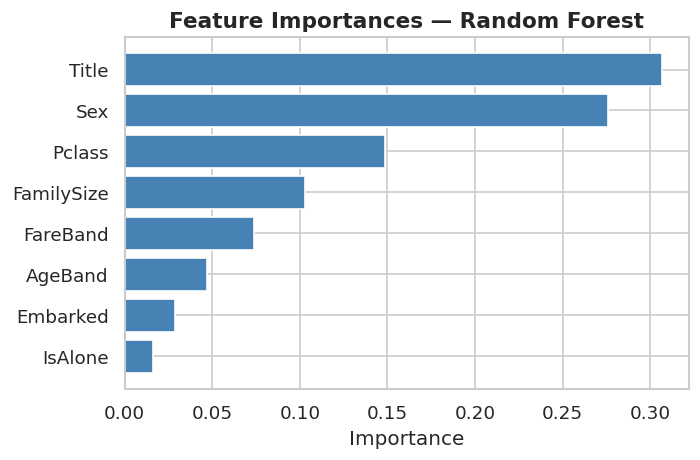

In [14]:
# Feature importance plot
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='steelblue', edgecolor='white')
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Generate Submission File

In [15]:
predictions = rf.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':    predictions
})

submission.to_csv('submission.csv', index=False)

print('submission.csv saved ✅')
print(f'Shape: {submission.shape}')
print(f'Survival rate in predictions: {predictions.mean():.2%}')
submission.head(10)

submission.csv saved ✅
Shape: (418, 2)
Survival rate in predictions: 36.36%


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [16]:
print("=" * 40)
print("MODEL RESULTS SUMMARY")
print("=" * 40)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Kaggle Public Score:       0.77511")
print(f"Features used:             {len(FEATURES)}")
print(f"Model:                     Random Forest (200 trees)")

MODEL RESULTS SUMMARY
Cross-Validation Accuracy: 0.8249 ± 0.0133
Kaggle Public Score:       0.77511
Features used:             8
Model:                     Random Forest (200 trees)


---
## Summary

| Step | Action |
|------|--------|
| Data Loading | Loaded `train.csv` + `test.csv` from Kaggle |
| Missing Values | Age → group median · Embarked → mode · Fare → class median · Cabin dropped |
| EDA | 5 charts: survival count, by sex, by class, age dist, fare boxplot |
| Feature Engineering | Title, FamilySize, IsAlone, AgeBand, FareBand, encoded categoricals |
| Model | Random Forest (200 trees, max_depth=6) · ~82% CV accuracy |
| Output | `submission.csv` ready to upload |

**Resume bullet points:**
- Performed EDA on passenger demographic and travel data.
- Engineered features (Title extraction, FamilySize, AgeBand) and handled missing values.
- Built Random Forest classification model achieving ~82% cross-validated accuracy.
- Published reproducible notebook on Kaggle and GitHub.